In [20]:
from langgraph.graph import MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START
from langgraph.checkpoint.memory import InMemorySaver

In [21]:
load_dotenv()

True

In [22]:
llm = ChatGroq(model="openai/gpt-oss-120b")

In [23]:
class ChatState(MessagesState):
    summary:str

In [24]:
def summarize_convo(state:ChatState):

    existing_summary =  state['summary']

    if existing_summary:
        prompt=(
            f"Existing summary {existing_summary} \n\n "
            "Extend the summary using the new conversation above"
        )
    else :  
        prompt = "Summarize the conversation above"

    messages_for_summary = state['messages'] + [HumanMessage(content=prompt)]

    response = llm.invoke(messages_for_summary)

    messages_to_delete = state['messages'][:-2]

    return {
        "summary":response.content,
        "messages":[RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [25]:
def chat(state:ChatState):
    msg=[]

    if state['summary']:
        msg.append({
            "role":"system",
            "content":f"Conversation summary:\n{state['summary']}"
            })
        
    msg.extend(state["messages"])

    print(msg)

    response = llm.invoke(msg)

    return {"messages":[response]}
    

In [26]:
def should_summarize(state:ChatState):
    return len(state["messages"])>6


In [27]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat)
builder.add_node("summarize", summarize_convo)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    should_summarize,
    {
        True: "summarize",
        False: "__end__",
    }
)

builder.add_edge("summarize", "__end__")

In [28]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

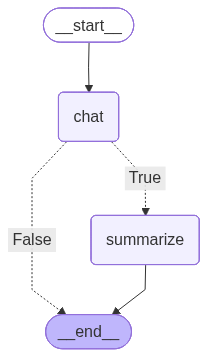

In [29]:
graph

In [30]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [31]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [32]:
run_turn('Quantum Physics in 20 words')
show_state()

[HumanMessage(content='Quantum Physics in 20 words', additional_kwargs={}, response_metadata={}, id='64f23831-e3c4-4bed-95d5-e40f29539ed7')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics in 20 words
- AIMessage : Quantum physics studies particles' wave-particle duality, quantized energy, unce


In [33]:
run_turn('How is Albert Einstien related in 20 words?')
show_state()

[HumanMessage(content='Quantum Physics in 20 words', additional_kwargs={}, response_metadata={}, id='64f23831-e3c4-4bed-95d5-e40f29539ed7'), AIMessage(content="Quantum physics studies particles' wave-particle duality, quantized energy, uncertainty, superposition, entanglement, and probabilistic nature of reality at microscopic scales universally.", additional_kwargs={'reasoning_content': 'The user asks: "Quantum Physics in 20 words". They want a brief description of quantum physics limited to 20 words. So we need to produce exactly 20 words. Let\'s count. Provide concise definition. For example: "Quantum physics studies particles\' wave-particle duality, quantized energy, uncertainty, superposition, entanglement, and probabilistic nature of reality." Count words: Quantum(1) physics(2) studies(3) particles\'(4) wave-particle(5) duality,(6) quantized(7) energy,(8) uncertainty,(9) superposition,(10) entanglement,(11) and(12) probabilistic(13) nature(14) of(15) reality(16). That\'s 16 word

In [34]:
run_turn('What are some of Einstien"s fampus work in 20 words')
show_state()

[HumanMessage(content='Quantum Physics in 20 words', additional_kwargs={}, response_metadata={}, id='64f23831-e3c4-4bed-95d5-e40f29539ed7'), AIMessage(content="Quantum physics studies particles' wave-particle duality, quantized energy, uncertainty, superposition, entanglement, and probabilistic nature of reality at microscopic scales universally.", additional_kwargs={'reasoning_content': 'The user asks: "Quantum Physics in 20 words". They want a brief description of quantum physics limited to 20 words. So we need to produce exactly 20 words. Let\'s count. Provide concise definition. For example: "Quantum physics studies particles\' wave-particle duality, quantized energy, uncertainty, superposition, entanglement, and probabilistic nature of reality." Count words: Quantum(1) physics(2) studies(3) particles\'(4) wave-particle(5) duality,(6) quantized(7) energy,(8) uncertainty,(9) superposition,(10) entanglement,(11) and(12) probabilistic(13) nature(14) of(15) reality(16). That\'s 16 word

In [35]:
run_turn('Explain special theory of relativity in 20 words')
show_state()

[HumanMessage(content='Quantum Physics in 20 words', additional_kwargs={}, response_metadata={}, id='64f23831-e3c4-4bed-95d5-e40f29539ed7'), AIMessage(content="Quantum physics studies particles' wave-particle duality, quantized energy, uncertainty, superposition, entanglement, and probabilistic nature of reality at microscopic scales universally.", additional_kwargs={'reasoning_content': 'The user asks: "Quantum Physics in 20 words". They want a brief description of quantum physics limited to 20 words. So we need to produce exactly 20 words. Let\'s count. Provide concise definition. For example: "Quantum physics studies particles\' wave-particle duality, quantized energy, uncertainty, superposition, entanglement, and probabilistic nature of reality." Count words: Quantum(1) physics(2) studies(3) particles\'(4) wave-particle(5) duality,(6) quantized(7) energy,(8) uncertainty,(9) superposition,(10) entanglement,(11) and(12) probabilistic(13) nature(14) of(15) reality(16). That\'s 16 word